In [1]:
from PIL import Image

img = Image.open("new-project-86-20240910153637953.jpg")
print(type(img))

<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [2]:
img = Image.open("new-project-86-20240910153637953.jpg")
print(img.format)

JPEG


In [3]:
img = Image.open("new-project-86-20240910153637953.jpg")
print(img.format)

JPEG


In [5]:
img = Image.open("new-project-86-20240910153637953.jpg")
print(img.format)
print(img.mode)

JPEG
RGB


In [6]:
import cv2


img = cv2.imread("new-project-86-20240910153637953.jpg")

print("Image shape:", img.shape)


if len(img.shape) == 3:
    print("Mode: Color (BGR)")
elif len(img.shape) == 2:
    print("Mode: Grayscale")

print("Data type:", img.dtype)

Image shape: (720, 1280, 3)
Mode: Color (BGR)
Data type: uint8


# Image to Tensors

In [7]:
from PIL import Image
import numpy as np

img = Image.open("new-project-86-20240910153637953.jpg")

img_array = np.array(img)

print(type(img_array))
print(img_array.shape)

<class 'numpy.ndarray'>
(720, 1280, 3)


In [11]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [12]:
from PIL import Image
from torchvision import transforms

img = Image.open("new-project-86-20240910153637953.jpg")

transform = transforms.ToTensor()

tensor_img = transform(img)

print(type(tensor_img))
print(tensor_img.shape)

<class 'torch.Tensor'>
torch.Size([3, 720, 1280])


# Normalization

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


img = Image.open("new-project-86-20240910153637953.jpg").convert("RGB")


img_array = np.array(img)

print("Before normalization")
print("Type:", type(img_array))
print("Shape:", img_array.shape)
print("Min pixel value:", img_array.min())
print("Max pixel value:", img_array.max())



Before normalization
Type: <class 'numpy.ndarray'>
Shape: (720, 1280, 3)
Min pixel value: 0
Max pixel value: 255


# Normalize: 0-255 -> 0-1

In [ ]:

img_array_norm = img_array / 255.0

print("\nAfter normalization")
print("Type:", type(img_array_norm))
print("Shape:", img_array_norm.shape)
print("Min pixel value:", img_array_norm.min())
print("Max pixel value:", img_array_norm.max())



After normalization
Type: <class 'numpy.ndarray'>
Shape: (720, 1280, 3)
Min pixel value: 0.0
Max pixel value: 1.0


# Original vs normalized image

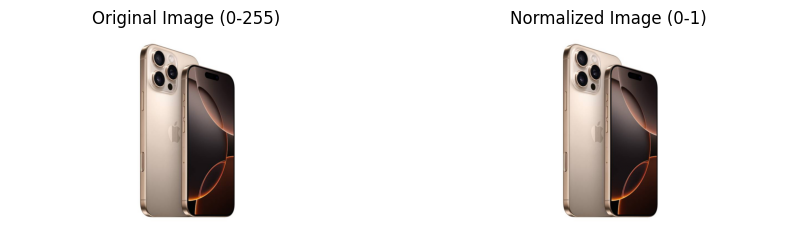

In [15]:

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Original Image (0-255)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_array_norm)
plt.title("Normalized Image (0-1)")
plt.axis("off")

plt.show()

# Pytorch

In [16]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt


img = Image.open("new-project-86-20240910153637953.jpg").convert("RGB")

img_array = np.array(img)



In [17]:
# Convert to tensor
tensor_img = torch.tensor(img_array, dtype=torch.float32)

print("Before normalization")
print("Type:", type(tensor_img))
print("Shape:", tensor_img.shape)   # (H, W, C)
print("Min:", tensor_img.min().item())
print("Max:", tensor_img.max().item())

# Normalize: 0-255 -> 0-1
tensor_img = tensor_img / 255.0

print("\nAfter normalization")
print("Type:", type(tensor_img))
print("Shape:", tensor_img.shape)   # still (H, W, C)
print("Min:", tensor_img.min().item())
print("Max:", tensor_img.max().item())



Before normalization
Type: <class 'torch.Tensor'>
Shape: torch.Size([720, 1280, 3])
Min: 0.0
Max: 255.0

After normalization
Type: <class 'torch.Tensor'>
Shape: torch.Size([720, 1280, 3])
Min: 0.0
Max: 1.0



After permute to PyTorch format
Shape: torch.Size([3, 720, 1280])


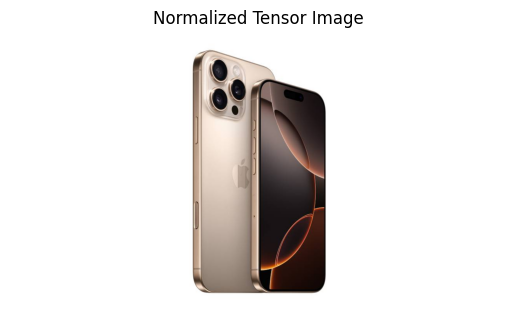

In [18]:
# Change to PyTorch format: (C, H, W)
tensor_img_chw = tensor_img.permute(2, 0, 1)

print("\nAfter permute to PyTorch format")
print("Shape:", tensor_img_chw.shape)   # (C, H, W)

# Display image again
plt.imshow(tensor_img)
plt.title("Normalized Tensor Image")
plt.axis("off")
plt.show()

# Torchvision bn

In [19]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Load image
img = Image.open("new-project-86-20240910153637953.jpg").convert("RGB")



Tensor type: <class 'torch.Tensor'>
Tensor shape: torch.Size([3, 720, 1280])
Min: 0.0
Max: 1.0


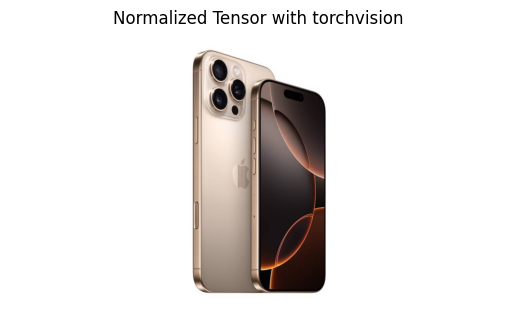

In [20]:
# ToTensor() converts:
# PIL image -> torch tensor
# pixel values 0-255 -> 0-1
transform = transforms.ToTensor()

tensor_img = transform(img)

print("Tensor type:", type(tensor_img))
print("Tensor shape:", tensor_img.shape)   # (C, H, W)
print("Min:", tensor_img.min().item())
print("Max:", tensor_img.max().item())

# Show image
plt.imshow(tensor_img.permute(1, 2, 0))
plt.title("Normalized Tensor with torchvision")
plt.axis("off")
plt.show()

# All step

NumPy array shape: (720, 1280, 3)
NumPy min/max: 0 255
Normalized NumPy min/max: 0.0 1.0
Tensor shape before permute: torch.Size([720, 1280, 3])
Tensor shape after permute: torch.Size([3, 720, 1280])


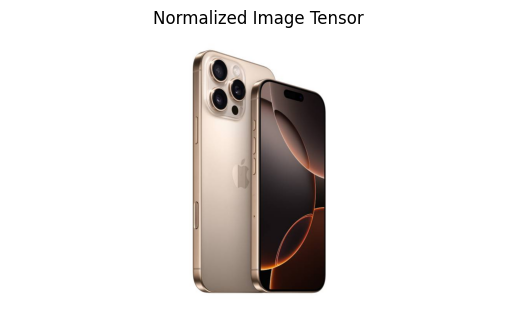

In [21]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Step 1: Load image
img = Image.open("new-project-86-20240910153637953.jpg").convert("RGB")

# Step 2: Convert image to NumPy array
img_array = np.array(img)
print("NumPy array shape:", img_array.shape)
print("NumPy min/max:", img_array.min(), img_array.max())

# Step 3: Normalize NumPy array
img_array_norm = img_array / 255.0
print("Normalized NumPy min/max:", img_array_norm.min(), img_array_norm.max())

# Step 4: Convert normalized array to tensor
tensor_img = torch.tensor(img_array_norm, dtype=torch.float32)
print("Tensor shape before permute:", tensor_img.shape)  # (H, W, C)

# Step 5: Convert to PyTorch format
tensor_img = tensor_img.permute(2, 0, 1)
print("Tensor shape after permute:", tensor_img.shape)   # (C, H, W)

# Step 6: Show image
plt.imshow(tensor_img.permute(1, 2, 0))
plt.title("Normalized Image Tensor")
plt.axis("off")
plt.show()

# Pixels in Array

In [22]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Step 1: Load image
img = Image.open("new-project-86-20240910153637953.jpg").convert("RGB")

# Step 2: Convert image to NumPy array
img_array = np.array(img)

print("Image shape:", img_array.shape)
print("\nFirst few pixel values (3x3 region):\n")

# Step 3: Show pixel values (first 3x3 pixels)
print(img_array[0:3, 0:3])

Image shape: (720, 1280, 3)

First few pixel values (3x3 region):

[[[255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]]]


In [23]:
import numpy as np

sample_pixels = np.array([
    [[123,  45, 200],
     [100, 255,  34],
     [ 76,  23,  98]],

    [[ 34,  67, 120],
     [255, 200, 150],
     [  0,  34,  90]],

    [[ 12,  44,  88],
     [ 98, 111, 255],
     [200, 201, 202]]
], dtype=np.float32)

print("Before normalization:")
print(sample_pixels)


normalized_pixels = sample_pixels / 255.0

print("\nAfter normalization:")
print(normalized_pixels)

print("\nMin value before:", sample_pixels.min())
print("Max value before:", sample_pixels.max())

print("\nMin value after:", normalized_pixels.min())
print("Max value after:", normalized_pixels.max())

Before normalization:
[[[123.  45. 200.]
  [100. 255.  34.]
  [ 76.  23.  98.]]

 [[ 34.  67. 120.]
  [255. 200. 150.]
  [  0.  34.  90.]]

 [[ 12.  44.  88.]
  [ 98. 111. 255.]
  [200. 201. 202.]]]

After normalization:
[[[0.48235294 0.1764706  0.78431374]
  [0.39215687 1.         0.13333334]
  [0.29803923 0.09019608 0.38431373]]

 [[0.13333334 0.2627451  0.47058824]
  [1.         0.78431374 0.5882353 ]
  [0.         0.13333334 0.3529412 ]]

 [[0.04705882 0.17254902 0.34509805]
  [0.38431373 0.43529412 1.        ]
  [0.78431374 0.7882353  0.7921569 ]]]

Min value before: 0.0
Max value before: 255.0

Min value after: 0.0
Max value after: 1.0
